# Student Risk Prediction Model

## Objective
This project aims to develop a predictive model that estimates the probability of a student entering a risk state of academic delay.

The analysis follows a structured pipeline:
1. Data understanding
2. Data cleaning and preprocessing
3. Exploratory data analysis (EDA)
4. Feature engineering
5. Model training
6. Evaluation and selection
7. Conclusion

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import joblib

## Data Loading

The dataset is loaded using a relative path to ensure portability.

In [2]:
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "base_de_dados_completo_eda.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,data_referencia,ra,fase,turma,nome,ano_nasc,idade_22,gênero,ano_ingresso,instituição_de_ensino,...,ing,fase_ideal.1,destaque_ipv_1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo/inativo,ativo/inativo_1
0,2022-01-01,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,RA-61,5,B,Aluno-61,2007.0,15.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,RA-610,1,L,Aluno-610,2013.0,9.0,Menina,2022,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,RA-611,1,M,Aluno-611,2010.0,12.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,RA-612,1,M,Aluno-612,2012.0,10.0,Menina,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 64 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data_referencia        3030 non-null   object 
 1   ra                     3030 non-null   object 
 2   fase                   3030 non-null   object 
 3   turma                  3030 non-null   object 
 4   nome                   860 non-null    object 
 5   ano_nasc               860 non-null    float64
 6   idade_22               860 non-null    float64
 7   gênero                 3030 non-null   object 
 8   ano_ingresso           3030 non-null   int64  
 9   instituição_de_ensino  3029 non-null   object 
 10  pedra_20               754 non-null    object 
 11  pedra_21               1061 non-null   object 
 12  pedra_22               1932 non-null   object 
 13  inde_22                1932 non-null   float64
 14  cg                     860 non-null    float64
 15  cf  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ano_nasc,860.0,2009.861628,2.771998,2001.000000,2008.000000,2010.000000,2012.000000,2015.0000
idade_22,860.0,12.138372,2.771998,7.000000,10.000000,12.000000,14.000000,21.0000
ano_ingresso,3030.0,2021.563696,1.822171,2016.000000,2021.000000,2022.000000,2023.000000,2024.0000
inde_22,1932.0,7.187687,0.954370,3.031806,6.671442,7.306000,7.863000,9.4420
cg,860.0,430.516279,248.432761,1.000000,215.750000,430.500000,645.250000,862.0000
cf,860.0,75.519767,52.312670,1.000000,30.000000,67.000000,118.000000,192.0000
ct,860.0,6.598837,3.975858,1.000000,3.000000,6.000000,9.000000,18.0000
nº_av,2954.0,3.031821,1.063670,0.000000,2.000000,3.000000,4.000000,6.0000
iaa,2865.0,7.918225,2.626209,0.000000,7.900000,8.751000,9.500000,10.0020
ieg,2954.0,7.945696,2.152281,0.000000,7.300000,8.600000,9.400000,10.0000


In [5]:
df.columns.tolist()

['data_referencia',
 'ra',
 'fase',
 'turma',
 'nome',
 'ano_nasc',
 'idade_22',
 'gênero',
 'ano_ingresso',
 'instituição_de_ensino',
 'pedra_20',
 'pedra_21',
 'pedra_22',
 'inde_22',
 'cg',
 'cf',
 'ct',
 'nº_av',
 'avaliador1',
 'rec_av1',
 'avaliador2',
 'rec_av2',
 'avaliador3',
 'rec_av3',
 'avaliador4',
 'rec_av4',
 'iaa',
 'ieg',
 'ips',
 'rec_psicologia',
 'ida',
 'matem',
 'portug',
 'inglês',
 'indicado',
 'atingiu_pv',
 'ipv',
 'ian',
 'fase_ideal',
 'defasagem',
 'destaque_ieg',
 'destaque_ida',
 'destaque_ipv',
 'ano_referencia',
 'inde_2023',
 'pedra_2023',
 'nome_anonimizado',
 'data_de_nasc',
 'idade',
 'pedra_23',
 'inde_23',
 'ipp',
 'mat',
 'por',
 'ing',
 'fase_ideal.1',
 'destaque_ipv_1',
 'inde_2024',
 'pedra_2024',
 'avaliador5',
 'avaliador6',
 'escola',
 'ativo/inativo',
 'ativo/inativo_1']

## Data Cleaning

Basic preprocessing steps:
- Remove duplicates
- Handle missing values
- Ensure consistent data types

In [6]:
# Remove duplicates

df_model = df.copy()
df_model = df_model.drop_duplicates()

In [7]:
# Missing values

missing = df_model.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

destaque_ipv_1           3030
avaliador6               3024
avaliador5               2882
inglês                   2747
rec_av4                  2734
pedra_23                 2340
inde_23                  2340
pedra_20                 2276
ing                      2222
matem                    2172
portug                   2172
rec_av3                  2170
ano_nasc                 2170
fase_ideal               2170
destaque_ieg             2170
rec_psicologia           2170
destaque_ida             2170
destaque_ipv             2170
nome                     2170
rec_av2                  2170
indicado                 2170
rec_av1                  2170
idade_22                 2170
atingiu_pv               2170
ct                       2170
cf                       2170
cg                       2170
pedra_2023               2099
inde_2023                2099
avaliador4               1979
pedra_21                 1969
inde_2024                1938
pedra_2024               1938
escola    

In [8]:
# Fill numeric missing values with median
numeric_cols = df_model.select_dtypes(include=np.number).columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

## Data Cleaning
Data Transformation (Pivot) and keeping only students with complete temporal data.

In [9]:
df_pivot = df.pivot_table(
    index="ra",
    columns="ano_referencia",
    values=["ian", "ida", "ieg", "ipv"],
    aggfunc="mean"
)

df_pivot.columns = [f"{col[0]}_{col[1]}" for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

In [10]:
df_model = df_pivot.copy()

df_model = df_model.dropna(subset=[
    "ian_2022", "ian_2023", "ian_2024",
    "ida_2022", "ida_2023",
    "ieg_2022", "ieg_2023",
    "ipv_2022", "ipv_2023"
])

## Data Preparation
Filter dataset to include only students with complete historical data.

In [11]:
# Keep only students with valid data for modeling
df_model = df_pivot.dropna(subset=["ian_2022", "ian_2024"]).copy()
df_model.shape

(472, 13)

## Target Engineering
Define the target variable based on performance variation.

In [12]:
df_model["risco_defasagem"] = np.where(
    df_model["ian_2024"] - df_model["ian_2022"] < 0,
    1,
    0
)

df_model["risco_defasagem"].value_counts()

risco_defasagem
0    442
1     30
Name: count, dtype: int64

## Feature Engineering
Create additional features to capture performance trends.

In [13]:
df_model["delta_ian"] = df_model["ian_2023"] - df_model["ian_2022"]
df_model["delta_ida"] = df_model["ida_2023"] - df_model["ida_2022"]
df_model["delta_ieg"] = df_model["ieg_2023"] - df_model["ieg_2022"]

## Exploratory Data Analysis

In [14]:
df_model.describe()

,ian_2022,ian_2023,ian_2024,ida_2022,ida_2023,ida_2024,ieg_2022,ieg_2023,ieg_2024,ipv_2022,ipv_2023,ipv_2024,risco_defasagem,delta_ian,delta_ida,delta_ieg
count,472.000000,468.000000,472.000000,472.000000,444.000000,445.000000,472.000000,444.000000,472.000000,472.000000,444.000000,445.000000,472.000000,468.000000,444.000000,444.000000
mean,6.594280,7.083333,8.252119,6.652331,6.775225,6.205281,8.466102,8.737162,7.503706,7.555235,8.070648,7.294657,0.063559,0.486111,0.079505,0.216441
std,2.391623,2.483888,2.403332,1.814203,1.443478,2.027192,1.309412,1.026001,2.558212,0.959776,0.874395,1.106570,0.244225,2.696520,1.561503,0.989254
min,2.500000,2.500000,2.500000,1.300000,2.200000,0.000000,0.000000,3.700000,0.000000,3.792000,5.540000,2.943333,0.000000,-5.000000,-5.700000,-2.800000
25%,5.000000,5.000000,5.000000,5.575000,5.900000,4.750000,7.975000,8.100000,6.451569,7.104000,7.491875,6.707500,0.000000,0.000000,-0.900000,-0.300000
50%,5.000000,5.000000,10.000000,7.000000,6.900000,6.500000,8.800000,9.000000,8.161977,7.500000,8.113333,7.443333,0.000000,0.000000,-0.100000,0.200000
75%,10.000000,10.000000,10.000000,8.000000,7.825000,7.750000,9.300000,9.500000,9.473684,8.167000,8.672500,8.042500,0.000000,0.000000,1.000000,0.725000
max,10.000000,10.000000,10.000000,9.900000,9.900000,9.833333,10.000000,10.000000,10.000000,10.000000,10.010000,9.623333,1.000000,7.500000,5.300000,4.700000


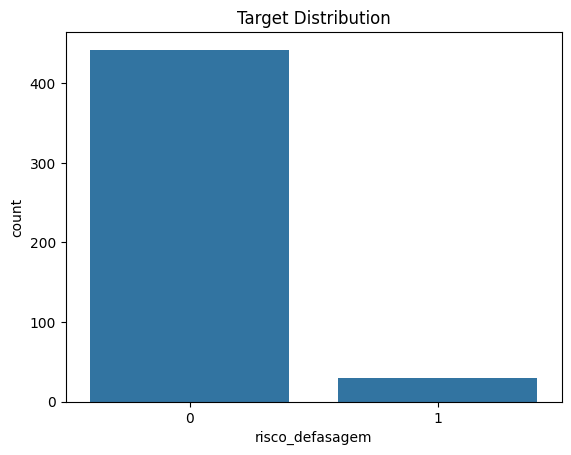

In [15]:
# Target distribution
sns.countplot(x="risco_defasagem", data=df_model)
plt.title("Target Distribution")
plt.show()

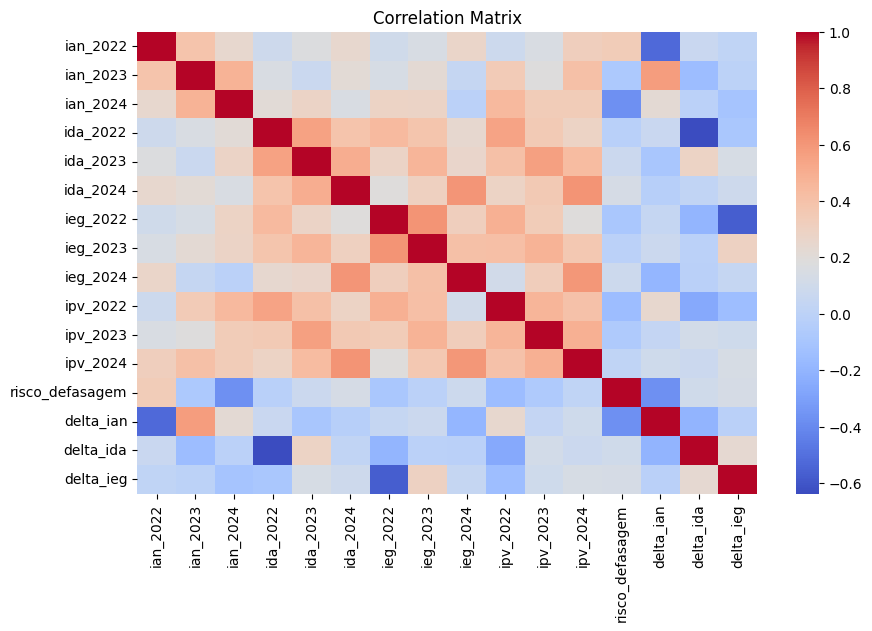

In [16]:
# Correlation matrix
numeric_df = df_model.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

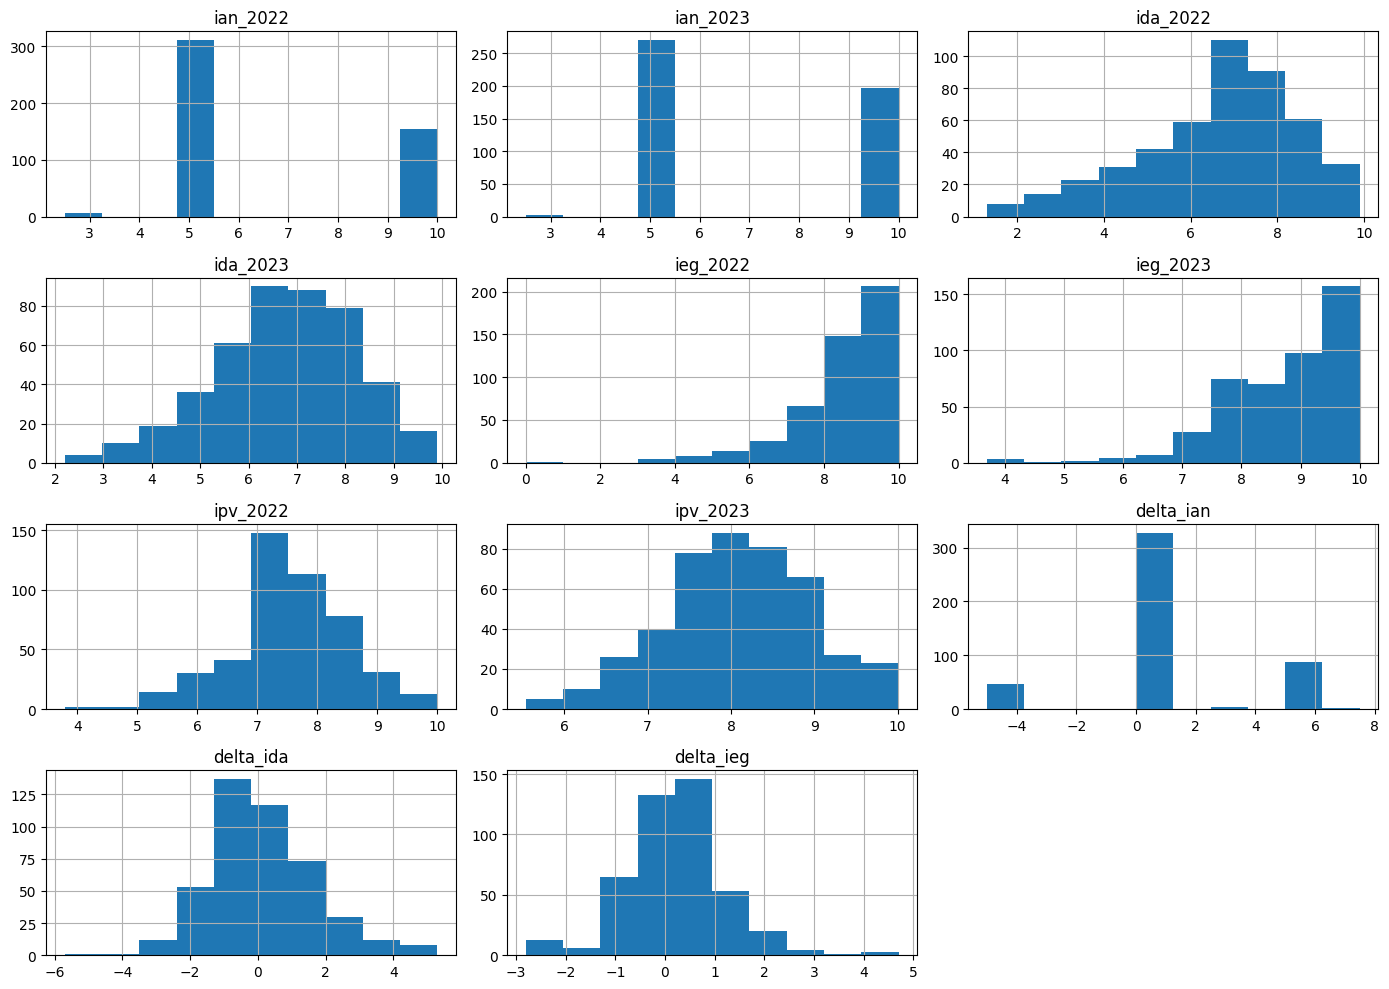

In [17]:
# Updated feature distributions based on new dataset (with 2023 + deltas)

cols_to_plot = [
    "ian_2022", "ian_2023",
    "ida_2022", "ida_2023",
    "ieg_2022", "ieg_2023",
    "ipv_2022", "ipv_2023",
    "delta_ian", "delta_ida", "delta_ieg"
]

df_model[cols_to_plot].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

## Feature Selection

In [18]:
df_model["delta_ian"] = df_model["ian_2023"] - df_model["ian_2022"]
df_model["ratio_ian"] = df_model["ian_2023"] / (df_model["ian_2022"] + 1e-6)


In [19]:
# Focus only on temporal signal (stronger features)

features = [
  
    "ian_2023",
    "ian_2022",
    "delta_ian",
    "ratio_ian"
]

TARGET = "risco_defasagem"

X = df_model[features]
y = df_model[TARGET]

## Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    min_samples_leaf= 1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

## Threshold Optimization

In [22]:
from sklearn.metrics import classification_report

# Probabilities from model
proba = model.predict_proba(X_test)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5]

best_threshold = 0.2
best_recall = 0

for t in thresholds:
    preds = (proba >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True)
    
    recall = report["1"]["recall"]
    
    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("Best threshold:", best_threshold)
print("Recall (class 1):", best_recall)

Best threshold: 0.2
Recall (class 1): 0.8333333333333334


## Model Export

In [23]:
threshold = 0.2

MODEL_PATH = BASE_DIR / "models" / "modelo_risco.pkl"

joblib.dump({
    "model": model,
    "threshold": threshold,
    "features": X.columns.tolist()
}, MODEL_PATH)

['c:\\Users\\luish\\student-risk-prediction\\models\\modelo_risco.pkl']